In [2]:
import pickle
import gzip
from matplotlib import pyplot as plt
import numpy as np
from script_corr import __batch_size__, __epoch_count__, min_window_size

epoch_count=__epoch_count__
batch_count=np.ceil(73200/__batch_size__/2)
min_window_size=min_window_size

file_name = f'corr_res_{0}.pkl.gz'
with gzip.open(file_name, 'rb') as f:
    temp = pickle.load(f)
    corr_y,  round_step, nan_ratios = list(zip(*temp))

round_step = np.array( round_step)
# temp_f = lambda idx: (min_window_size+idx)/(batch_count*epoch_count)
#  round_step = temp_f(np.arange(len( corr_y)))
corr_y = np.array( corr_y)

ModuleNotFoundError: No module named 'numpy._core'

In [6]:
with open('auc.txt') as f:
    auc = eval(f.read())


NameError: name 'round_step' is not defined

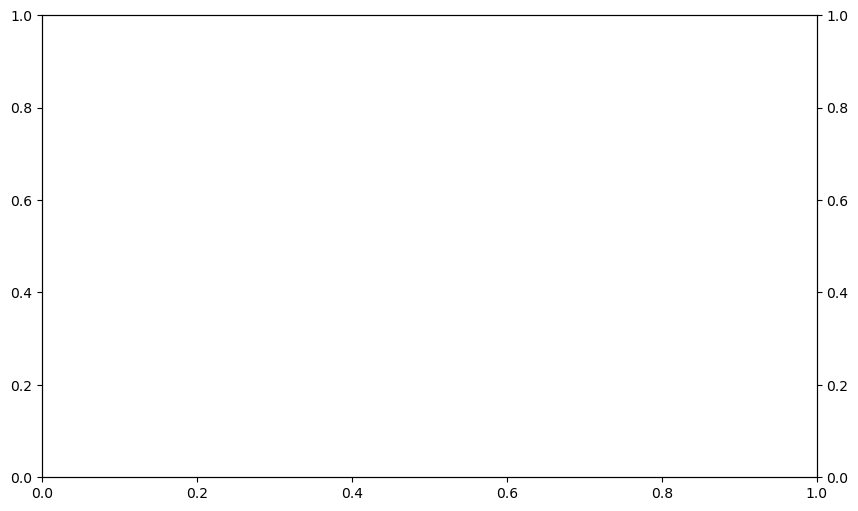

In [4]:
plt.figure(figsize=(10, 6))

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.bar(round_step,  corr_y, width=0.01)
ax1.xticks(list(range(int(np.floor( round_step.min())), int(np.ceil( round_step.max())+1))))
ax1.set_xlabel('Communication round (WINDOWS SIZE = 1.2 Rounds)')
ax1.set_ylabel('Mean Correlation between workers elements')

ax2.plot(np.arange(len(auc)), auc, marker='o', markersize=1, label='val AUC', color='orange')
ax2.set_ylabel('Validation AUC', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

ax1.tick_params(axis='y', labelcolor='#2E5BBA')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

ax1.grid(True)

plt.title('Correlation between elements of workers\' grad in ResNet18 on SVHN dataset')
plt.ylim(0.5, 1)
plt.xlim(1,25)
plt.grid()
plt.show()

(0.0, 1.0)

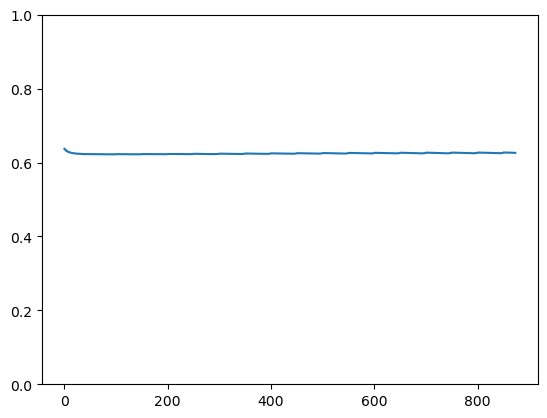

In [6]:
# share of nan values
plt.plot(nan_ratios)
plt.ylim(0, 1)

In [2]:
# import numpy as np
# import os
# import pickle
# import gzip
# from matplotlib import pyplot as plt
#
# epoch_count = 10
# batch_count = 3
#
# loaded_files = []
# x = []
# for file_name in os.listdir('accum_grads/'):
#     if not file_name.endswith('.pkl.gz'):
#         continue
#     with gzip.open(os.path.join('accum_grads/', file_name), 'rb') as f:
#         res = pickle.load(f)
#         loaded_files.append([None, res])
#     temp = {
#         "round_num": int(file_name.split(',')[0].split('_')[-1]),
#         "epoch_num": int(file_name.split(',')[1].split('_')[1]),
#         "batch_num": int(file_name.split(',')[2].split('_')[1].split('.')[0])
#     }
#     temp = temp['round_num'] + (temp['epoch_num'] + temp['batch_num'] / batch_count) / epoch_count
#     x.append(temp)
#     loaded_files[-1][0] = temp
#
# loaded_files.sort(key=lambda x: x[0])
# y = np.array([x[1] for x in loaded_files])
# x.sort()
# temp = [*np.isnan(y)]
# non_nan_idx = temp[0]
# ratios = [len(non_nan_idx) / len(y)]
# for i in range(1, len(temp)):
#     non_nan_idx = np.logical_or(non_nan_idx, temp[i])
#     ratios += [len(non_nan_idx) / len(y)]
# y = y.T[~non_nan_idx]
#
# y = np.mean(y, axis=0)
# print(y.shape, ratios[0], ratios[-1])
# plt.figure(figsize=(14, 6))
# plt.plot(x, y, )
# plt.xticks([0, 1, 2, 3, 4, ])
# plt.xlabel('Communication round (+epoch/10 + batch/3/10)')
# plt.ylabel('Correlation between workers')
# plt.title('Correlation between workers\' gradients in ResNet18 on SVHN dataset')
# plt.grid()
# plt.show()